# Task 2 — Classificazione BBC News (9 classi)


## 1. Import e caricamento dati


In [1]:
import pandas as pd
import numpy as np
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
from nltk.tokenize import RegexpTokenizer
from nltk import FreqDist
from nltk.corpus import stopwords

_tokenizer = RegexpTokenizer(r'\w+')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

import matplotlib.pyplot as plt

df = pd.read_csv("bbc_dataset_9classi.csv")
print(f"Dataset: {df.shape[0]} articoli, {df.shape[1]} colonne")
print(f"\nDistribuzione classi:\n{df['label'].value_counts()}")
df.head()


Dataset: 7049 articoli, 4 colonne

Distribuzione classi:
label
tennis               1000
other_sport          1000
rugby                1000
cricket              1000
non_sport            1000
football             1000
formula1              462
american_football     333
golf                  254
Name: count, dtype: int64


,title,text,label,url
0,Sabalenka takes on Pegula and crowd in US Open...,Aryna Sabalenka will have to deal with a boist...,tennis,https://www.bbc.com/sport/tennis/articles/cvg3...
1,From winning iPods to Grand Slams - Djokovic's...,Novak Djokovic continues to reach landmarks mo...,tennis,https://www.bbc.com/sport/tennis/articles/cdd4...
2,Chalmers targets World final after new persona...,Alastair Chalmers says he is targeting the 400...,other_sport,https://www.bbc.com/sport/athletics/articles/c...
3,Players flee court after UAE drone attack caus...,Players and officials ran from the court at an...,tennis,https://www.bbc.com/sport/tennis/articles/cx2g...
4,How will GB cope without Raducanu in BJK Cup?,Great Britain's Billie Jean King Cup captain A...,tennis,https://www.bbc.com/sport/tennis/videos/c79vq8...


## 2. Pre-processing: tokenizzazione e rimozione stopwords


In [2]:
STOP_WORDS = set(stopwords.words("english"))

def tokenizza_e_pulisci(testo: str) -> list[str]:
    tokens = _tokenizer.tokenize(testo.lower())
    return [
        t for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 2
    ]

df["tokens"] = df["text"].apply(tokenizza_e_pulisci)
print(f"Esempio tokens: {df.iloc[0]['tokens'][:15]}")


Esempio tokens: ['aryna', 'sabalenka', 'deal', 'boisterous', 'new', 'york', 'crowd', 'faces', 'home', 'hope', 'jessica', 'pegula', 'saturday', 'open', 'final']


## 3. Split train/test


In [3]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
print(f"Train: {len(df_train)} | Test: {len(df_test)}")
print(f"\nDistribuzione train:\n{df_train['label'].value_counts()}")


Train: 5639 | Test: 1410

Distribuzione train:
label
other_sport          800
tennis               800
non_sport            800
football             800
rugby                800
cricket              800
formula1             370
american_football    266
golf                 203
Name: count, dtype: int64


## 4. Analisi frequenze con FreqDist (per classe)

Con 9 classi calcoliamo una `FreqDist` separata per ciascuna. Per ogni parola il **rapporto di appartenenza** a una classe è: `freq_classe / freq_totale`.


In [4]:
CLASSI = ['non_sport', 'football', 'tennis', 'rugby', 'cricket', 'other_sport', 'formula1', 'american_football', 'golf']

# FreqDist per ciascuna classe (solo train)
fd = {}
for cls in CLASSI:
    tokens_cls = []
    for _, riga in df_train[df_train["label"] == cls].iterrows():
        tokens_cls.extend(riga["tokens"])
    fd[cls] = FreqDist(tokens_cls)
    print(f"  {cls:<20s}  {len(fd[cls]):,} parole uniche  ({sum(fd[cls].values()):,} token)")


  non_sport             40,299 parole uniche  (435,298 token)
  football              17,086 parole uniche  (187,048 token)
  tennis                14,664 parole uniche  (266,608 token)
  rugby                 15,603 parole uniche  (241,724 token)
  cricket               11,882 parole uniche  (170,764 token)
  other_sport           18,691 parole uniche  (222,265 token)
  formula1              9,737 parole uniche  (152,066 token)
  american_football     8,625 parole uniche  (93,377 token)
  golf                  8,196 parole uniche  (67,183 token)


## 5. Selezione keyword discriminanti per classe

Per ogni parola con frequenza totale ≥ 30, calcoliamo il rapporto su ogni classe. Se il rapporto ≥ 0.60 quella parola è una keyword di quella classe (abbassata la soglia rispetto al caso binario, che era 85%).


In [5]:
SOGLIA_FREQ_MIN = 30
SOGLIA_RATIO    = 0.60   

vocabolario = set()
for cls in CLASSI:
    vocabolario |= set(fd[cls].keys())

# keyword_per_classe[cls] = set di parole discriminanti per quella classe
keyword_per_classe = {cls: set() for cls in CLASSI}

for parola in vocabolario:
    freq_per_cls = {cls: fd[cls][parola] for cls in CLASSI}
    totale = sum(freq_per_cls.values())
    if totale < SOGLIA_FREQ_MIN:
        continue
    for cls in CLASSI:
        if freq_per_cls[cls] / totale >= SOGLIA_RATIO:
            keyword_per_classe[cls].add(parola)

for cls in CLASSI:
    print(f"  {cls:<20s}  {len(keyword_per_classe[cls]):4d} keyword")


  non_sport             1122 keyword
  football               181 keyword
  tennis                 256 keyword
  rugby                  277 keyword
  cricket                193 keyword
  other_sport            202 keyword
  formula1               147 keyword
  american_football      115 keyword
  golf                    56 keyword


## 6. Classificatore Rule-Based (multiclasse)

Per ogni articolo contiamo le keyword di ciascuna classe. La classe con il punteggio più alto vince. In caso di pareggio totale → `non_sport`.


In [6]:
def classificatore_rule_based(tokens: list[str], kw: dict) -> str:
    punteggi = {cls: sum(1 for t in tokens if t in kw[cls]) for cls in CLASSI}
    best_cls = max(punteggi, key=punteggi.get)
    if punteggi[best_cls] == 0:
        return "non_sport" 
    return best_cls

df_test = df_test.copy()
df_test["predizione"] = df_test["tokens"].apply(
    lambda t: classificatore_rule_based(t, keyword_per_classe)
)

print("Esempi di predizione:")
for _, riga in df_test.head(10).iterrows():
    ok = "✓" if riga["predizione"] == riga["label"] else "✗"
    print(f"  {ok} vero={riga['label']:20s}  pred={riga['predizione']:20s}  {riga['title'][:50]}")


Esempi di predizione:
  ✓ vero=football              pred=football              Blackpool sign Walters, Anderson and Clarkson
  ✓ vero=american_football     pred=american_football     What's behind the Irish impact in the NFL?
  ✓ vero=non_sport             pred=non_sport             Five lifestyle tweaks to help you live well for lo
  ✓ vero=tennis                pred=tennis                GB's Salisbury & Skupski reach Paris doubles final
  ✓ vero=rugby                 pred=rugby                 The father-son dynasties powering England's future
  ✓ vero=non_sport             pred=non_sport             'I can't breathe any more': Inside the night a mob
  ✓ vero=golf                  pred=golf                  The golfer who scored 10 on one hole in The Open
  ✓ vero=rugby                 pred=rugby                 Wales U20s aim to provide hope in 'dark time'
  ✓ vero=american_football     pred=american_football     Who are the NFL's play-off contenders and pretende
  ✓ vero=rugby   

## 7. Valutazione Baseline


In [7]:
y_true = df_test["label"]
y_pred = df_test["predizione"]
print(classification_report(y_true, y_pred, target_names=sorted(df["label"].unique())))


                   precision    recall  f1-score   support

american_football       0.95      0.91      0.93        67
          cricket       0.99      0.98      0.99       200
         football       0.98      0.82      0.89       200
         formula1       0.92      0.99      0.95        92
             golf       0.96      0.92      0.94        51
        non_sport       0.76      0.99      0.86       200
      other_sport       0.99      0.76      0.86       200
            rugby       0.95      0.98      0.97       200
           tennis       0.94      0.98      0.96       200

         accuracy                           0.92      1410
        macro avg       0.94      0.93      0.93      1410
     weighted avg       0.93      0.92      0.92      1410



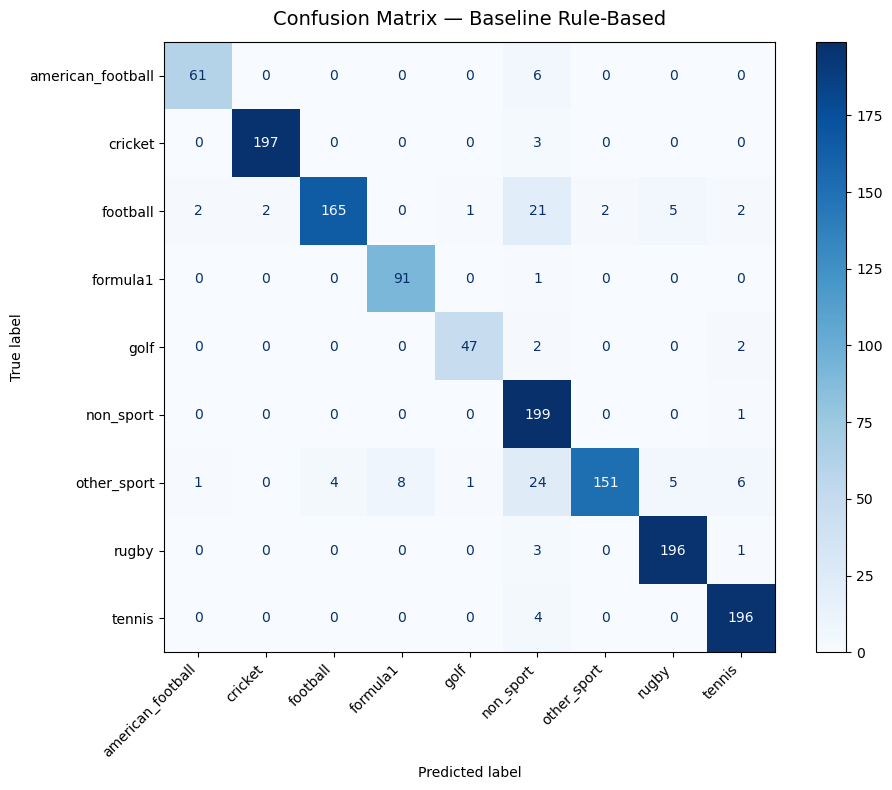

In [8]:
labels_ord = sorted(df["label"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ord)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — Baseline Rule-Based", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_baseline.png", dpi=150)
plt.show()


## 8. Regressione Logistica con TF-IDF

Pipeline TF-IDF + `LogisticRegression`. Con più di 2 classi scikit-learn usa automaticamente la **softmax** (regressione logistica multinomiale).


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train = df_train["text"]
X_test_text = df_test["text"]
y_train_lr = df_train["label"]
y_test_lr  = df_test["label"]

pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizza_e_pulisci,
        token_pattern=None,
        max_features=10_000,
        sublinear_tf=True,
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

pipeline_lr.fit(X_train, y_train_lr)
print("Training completato.")


Training completato.


## 9. Valutazione Regressione Logistica


In [10]:
y_pred_lr = pipeline_lr.predict(X_test_text)
print("=== Classification Report — Logistic Regression ===")
print(classification_report(y_test_lr, y_pred_lr, target_names=sorted(df["label"].unique())))


=== Classification Report — Logistic Regression ===
                   precision    recall  f1-score   support

american_football       1.00      0.94      0.97        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.97      0.98       200
         formula1       0.99      0.97      0.98        92
             golf       0.98      0.96      0.97        51
        non_sport       0.93      0.99      0.96       200
      other_sport       0.97      0.95      0.96       200
            rugby       0.99      0.99      0.99       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.98      1410
        macro avg       0.98      0.97      0.98      1410
     weighted avg       0.98      0.98      0.98      1410



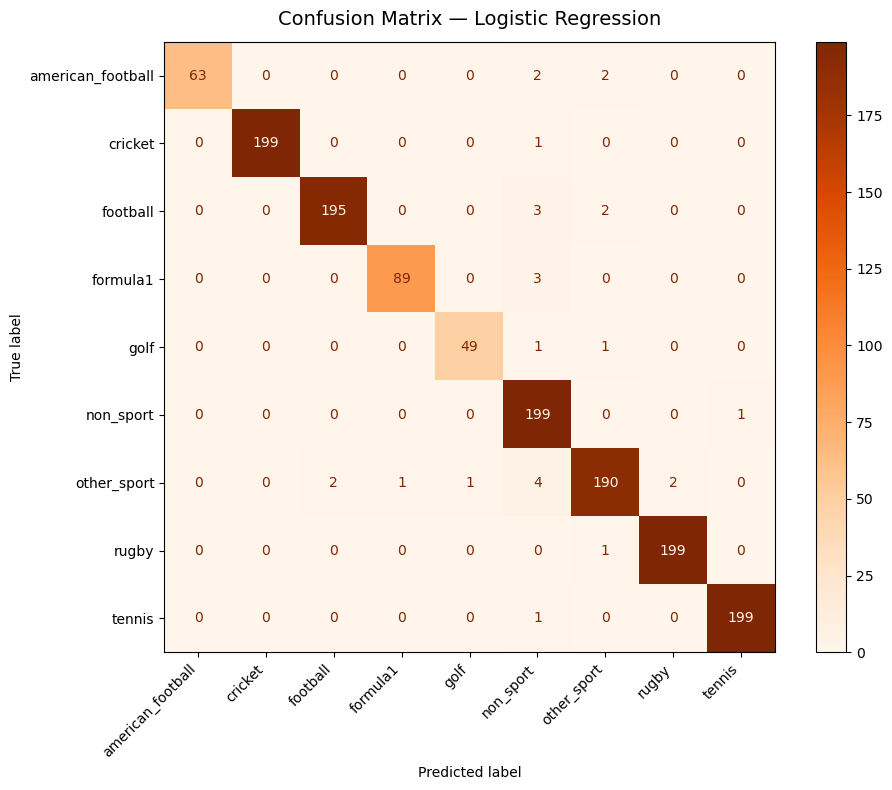

In [11]:
cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels_ord).plot(cmap="Oranges", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_lr.png", dpi=150)
plt.show()


## 10. Rete Neurale Feedforward

Architettura a 2 layer (come da slide):
- **Hidden layer**: `h = ReLU(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: SGD


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

# TF-IDF
tfidf_nn = TfidfVectorizer(
    tokenizer=tokenizza_e_pulisci,
    token_pattern=None,
    max_features=10_000,
    sublinear_tf=True,
)
X_train_tfidf = tfidf_nn.fit_transform(X_train).toarray().astype(np.float32)
X_test_tfidf  = tfidf_nn.transform(X_test_text).toarray().astype(np.float32)

# Label encoding numerico
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_lr).astype(np.int64)
y_test_enc  = le.transform(y_test_lr).astype(np.int64)

N_CLASSI = len(le.classes_)
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")

train_dataset = TensorDataset(
    torch.tensor(X_train_tfidf),
    torch.tensor(y_train_enc)
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [13]:
class FeedforwardNN(nn.Module):
    """
    Rete neurale feedforward a 2 layer:
      - Hidden: h = Tanh(Wx + b)
      - Output: y = softmax(Uh)  [9 classi]
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, n_classi)
        self.act    = nn.Tanh()

    def forward(self, x):
        h = self.act(self.hidden(x))   # hidden layer con Tanh
        return self.output(h)          # logit grezzi (CrossEntropyLoss applica softmax internamente)


INPUT_DIM  = X_train_tfidf.shape[1]
HIDDEN_DIM = 512
LR         = 0.01
EPOCHS     = 30

model_sgd     = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)
criterion_sgd = nn.CrossEntropyLoss()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=LR)

print(model_sgd)
print(f"Parametri totali: {sum(p.numel() for p in model_sgd.parameters()):,}")


FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 5,125,129


In [14]:
model_sgd.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer_sgd.zero_grad()
        loss = criterion_sgd(model_sgd(X_batch), y_batch)
        loss.backward()
        optimizer_sgd.step()
        total_loss += loss.item() * len(y_batch)
    print(f"Epoch {epoch:2d}/{EPOCHS}  |  loss: {total_loss / len(train_dataset):.4f}")
print("Training completato.")


Epoch  1/30  |  loss: 2.1782
Epoch  2/30  |  loss: 2.1492
Epoch  3/30  |  loss: 2.1292
Epoch  4/30  |  loss: 2.1149
Epoch  5/30  |  loss: 2.1043
Epoch  6/30  |  loss: 2.0958
Epoch  7/30  |  loss: 2.0887
Epoch  8/30  |  loss: 2.0824
Epoch  9/30  |  loss: 2.0766
Epoch 10/30  |  loss: 2.0708
Epoch 11/30  |  loss: 2.0650
Epoch 12/30  |  loss: 2.0590
Epoch 13/30  |  loss: 2.0525
Epoch 14/30  |  loss: 2.0457
Epoch 15/30  |  loss: 2.0382
Epoch 16/30  |  loss: 2.0301
Epoch 17/30  |  loss: 2.0211
Epoch 18/30  |  loss: 2.0114
Epoch 19/30  |  loss: 2.0006
Epoch 20/30  |  loss: 1.9889
Epoch 21/30  |  loss: 1.9759
Epoch 22/30  |  loss: 1.9618
Epoch 23/30  |  loss: 1.9462
Epoch 24/30  |  loss: 1.9291
Epoch 25/30  |  loss: 1.9106
Epoch 26/30  |  loss: 1.8904
Epoch 27/30  |  loss: 1.8685
Epoch 28/30  |  loss: 1.8449
Epoch 29/30  |  loss: 1.8194
Epoch 30/30  |  loss: 1.7923
Training completato.


## 11. Valutazione NN


In [15]:
model_sgd.eval()
with torch.no_grad():
    logits = model_sgd(torch.tensor(X_test_tfidf))
    y_pred_nn_sgd_enc = logits.argmax(dim=1).numpy()

y_pred_nn_sgd = le.inverse_transform(y_pred_nn_sgd_enc)

print("=== Classification Report — NN Feedforward ===")
print(classification_report(y_test_lr, y_pred_nn_sgd, target_names=sorted(df["label"].unique())))


=== Classification Report — NN Feedforward ===
                   precision    recall  f1-score   support

american_football       0.00      0.00      0.00        67
          cricket       0.98      0.99      0.99       200
         football       0.81      0.94      0.87       200
         formula1       0.00      0.00      0.00        92
             golf       0.00      0.00      0.00        51
        non_sport       0.67      0.99      0.80       200
      other_sport       0.73      0.78      0.75       200
            rugby       0.84      0.94      0.89       200
           tennis       0.83      0.99      0.90       200

         accuracy                           0.80      1410
        macro avg       0.54      0.63      0.58      1410
     weighted avg       0.69      0.80      0.74      1410



/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


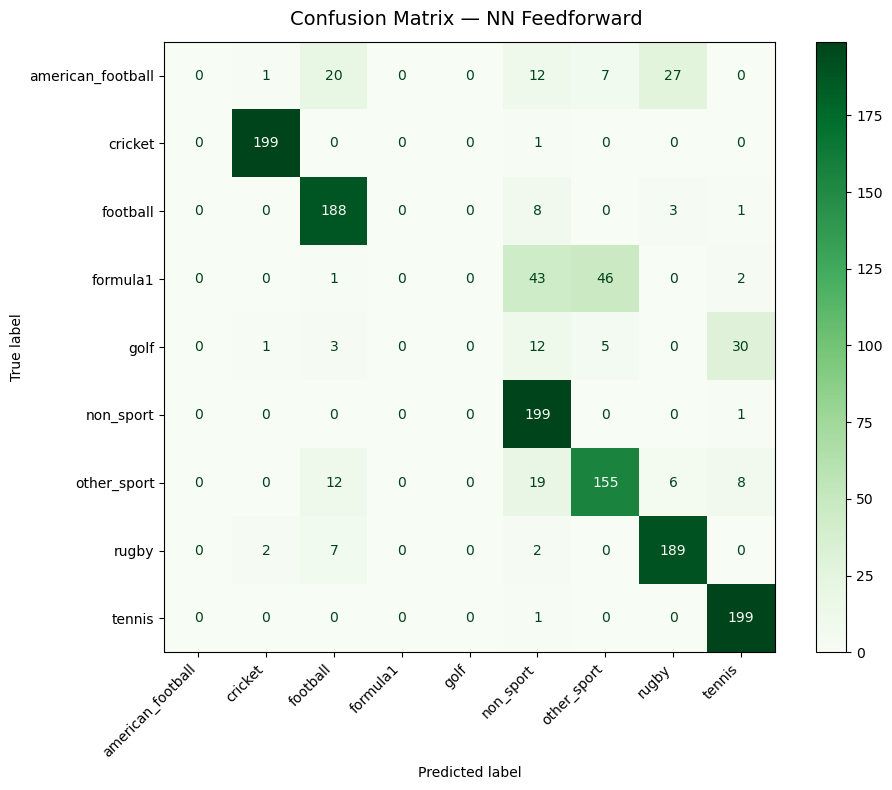

In [16]:
cm_nn = confusion_matrix(y_test_lr, y_pred_nn_sgd, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=labels_ord).plot(cmap="Greens", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — NN Feedforward ", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_nn.png", dpi=150)
plt.show()


## 12. Rete Neurale Feedforward — Adam + EarlyStopping

Architettura a 2 layer:
- **Hidden layer**: `h = Tanh(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: Adam
- **EarlyStopping**: si ferma automaticamente quando la loss non migliora

In [17]:
# I dati TF-IDF e il LabelEncoder sono già stati preparati nella sezione precedente,
# li riusiamo direttamente per la NN con Adam.
# Ricrea solo il DataLoader con gli stessi dati
train_dataset2 = TensorDataset(
    torch.tensor(X_train_tfidf),
    torch.tensor(y_train_enc)
)
train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")


Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [18]:
class FeedforwardNN(nn.Module):
    """
    Rete neurale feedforward a 2 layer:
      - Hidden: h = Tanh(Wx + b)
      - Output: y = softmax(Uh)  [9 classi]
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, n_classi)
        self.act    = nn.Tanh()

    def forward(self, x):
        h = self.act(self.hidden(x))   # hidden layer con Tanh
        return self.output(h)          # logit grezzi (CrossEntropyLoss applica softmax internamente)


INPUT_DIM  = X_train_tfidf.shape[1]
HIDDEN_DIM = 128
LR         = 0.001
EPOCHS     = 100

model     = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)
criterion = nn.CrossEntropyLoss()  # cross-entropy multiclasse (include softmax)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"Parametri totali: {sum(p.numel() for p in model.parameters()):,}")


FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 1,281,289


In [19]:
# EarlyStopping: si ferma se la loss non migliora per `patience` epoche consecutive
PATIENCE = 5

model.train()
best_loss = float('inf')
epochs_senza_miglioramento = 0

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for X_batch, y_batch in train_loader2:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    avg_loss = total_loss / len(train_dataset2)
    print(f"Epoch {epoch:3d}/{EPOCHS}  |  loss: {avg_loss:.4f}")

    # EarlyStopping
    if avg_loss < best_loss - 0.0005:  
        best_loss = avg_loss
        epochs_senza_miglioramento = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_senza_miglioramento += 1
        if epochs_senza_miglioramento >= PATIENCE:
            print(f"\nEarlyStopping: nessun miglioramento per {PATIENCE} epoche. Stop.")
            model.load_state_dict(best_weights)  # restore best weights
            break

print("Training completato.")


Epoch   1/100  |  loss: 0.9409
Epoch   2/100  |  loss: 0.0890
Epoch   3/100  |  loss: 0.0288
Epoch   4/100  |  loss: 0.0128
Epoch   5/100  |  loss: 0.0071
Epoch   6/100  |  loss: 0.0046
Epoch   7/100  |  loss: 0.0032
Epoch   8/100  |  loss: 0.0023
Epoch   9/100  |  loss: 0.0018
Epoch  10/100  |  loss: 0.0014
Epoch  11/100  |  loss: 0.0011
Epoch  12/100  |  loss: 0.0009
Epoch  13/100  |  loss: 0.0008
Epoch  14/100  |  loss: 0.0006
Epoch  15/100  |  loss: 0.0005
Epoch  16/100  |  loss: 0.0005
Epoch  17/100  |  loss: 0.0004
Epoch  18/100  |  loss: 0.0003
Epoch  19/100  |  loss: 0.0003
Epoch  20/100  |  loss: 0.0003

EarlyStopping: nessun miglioramento per 5 epoche. Stop.
Training completato.


## 13. Valutazione NN — Adam + EarlyStopping

In [20]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test_tfidf))
    y_pred_nn_enc = logits.argmax(dim=1).numpy()

y_pred_nn = le.inverse_transform(y_pred_nn_enc)

print("=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===")
print(classification_report(y_test_lr, y_pred_nn, target_names=sorted(df["label"].unique())))


=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===
                   precision    recall  f1-score   support

american_football       1.00      0.96      0.98        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.97      0.98       200
         formula1       0.99      0.99      0.99        92
             golf       0.98      1.00      0.99        51
        non_sport       0.96      0.99      0.98       200
      other_sport       0.98      0.97      0.97       200
            rugby       1.00      0.99      1.00       200
           tennis       1.00      1.00      1.00       200

         accuracy                           0.99      1410
        macro avg       0.99      0.99      0.99      1410
     weighted avg       0.99      0.99      0.99      1410



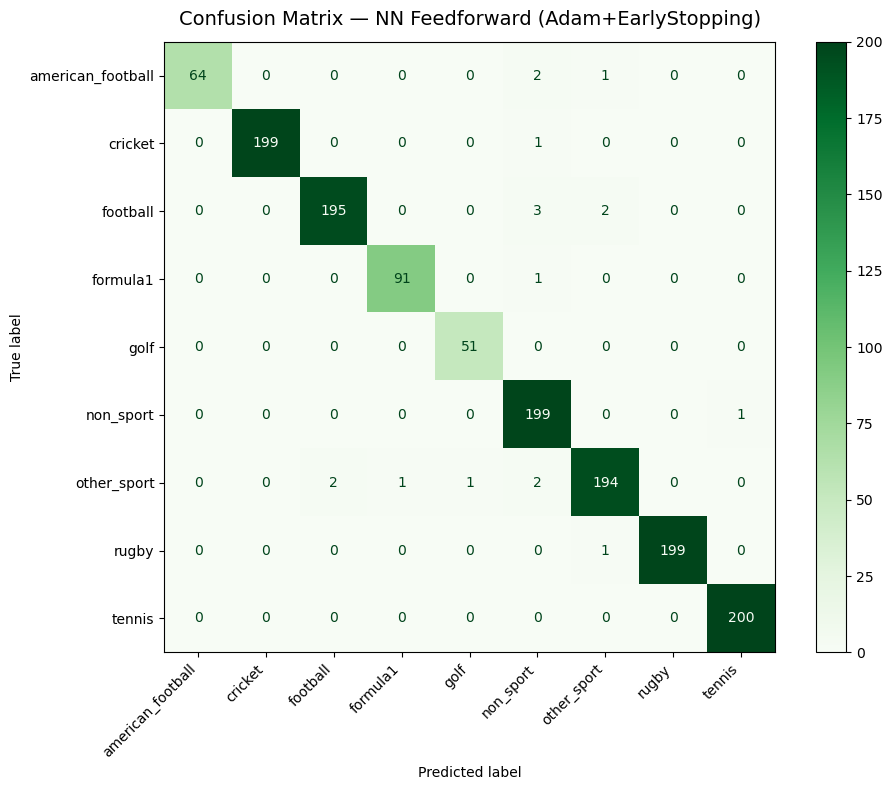

In [21]:
cm_nn = confusion_matrix(y_test_lr, y_pred_nn, labels=labels_ord)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=labels_ord).plot(cmap="Greens", ax=ax, values_format="d")
ax.set_title("Confusion Matrix — NN Feedforward (Adam+EarlyStopping)", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/confusion_matrix_nn_adam.png", dpi=150)
plt.show()


## 14. Confronto Finale

In [22]:
acc_baseline = accuracy_score(y_true, y_pred)
f1_baseline  = f1_score(y_true, y_pred, average="macro")

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average="macro")

acc_nn_sgd = accuracy_score(y_test_lr, y_pred_nn_sgd)
f1_nn_sgd  = f1_score(y_test_lr, y_pred_nn_sgd, average="macro")

acc_nn = accuracy_score(y_test_lr, y_pred_nn)
f1_nn  = f1_score(y_test_lr, y_pred_nn, average="macro")

print(f"{'Metodo':<35} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 57)
print(f"{'Baseline Rule-Based':<35} {acc_baseline:>10.4f} {f1_baseline:>10.4f}")
print(f"{'Logistic Regression (TF-IDF)':<35} {acc_lr:>10.4f} {f1_lr:>10.4f}")
print(f"{'NN Feedforward — SGD':<35} {acc_nn_sgd:>10.4f} {f1_nn_sgd:>10.4f}")
print(f"{'NN Feedforward — Adam+EarlyStopping':<35} {acc_nn:>10.4f} {f1_nn:>10.4f}")

Metodo                                Accuracy   F1 macro
---------------------------------------------------------
Baseline Rule-Based                     0.9241     0.9275
Logistic Regression (TF-IDF)            0.9801     0.9784
NN Feedforward — SGD                    0.8007     0.5781
NN Feedforward — Adam+EarlyStopping     0.9872     0.9869
